In [5]:
from src import *

In [6]:
width = 8.5 / 2.54 #inches

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb, physics}'


formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))

In [7]:
spade_mean, spade_var, spade_b = [], [], []
di_mean, di_var, di_b = [], [], []
for d in np.arange(0, 101, 2):
    spade_c = LoadEstimates(rf'data/noisy/spade_5px_f0.2_d{d}.npz')
    di_c = LoadEstimates(rf'data/noisy/di_5px_f0.2_d{d}.npz')

    spade_mean.append(spade_c.estimates.mean())
    spade_var.append(spade_c.estimates.var(ddof=1) * spade_c.photons)
    spade_b.append(spade_c.background / spade_c.photons)

    di_mean.append(di_c.estimates.mean())
    di_var.append(di_c.estimates.var(ddof=1) * di_c.photons)
    di_b.append(di_c.background / di_c.photons)

b_axis = np.linspace(1e-10, 0.2, 1000)
spade_crb = 1/SPADE.CFI(b_axis, DMD.A((4/pi) * 5), 0.2)
di_crb = 1/DI.CFI(b_axis, DMD.A((4/pi) * 5), 0.2)

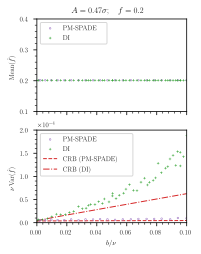

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(width, width*1.1), sharex=True)


spade_params = {
    'marker': 'o',
    'edgecolors': '#9467bd',
    'facecolors': 'none',
    's': 3,
    'linewidths': 0.5
}


di_params = {
    'marker': '+',
    'facecolor': '#2ca02c',

    's': 6,
    'linewidths': 0.5
}



ax[0].scatter(spade_b, spade_mean, **spade_params, label='PM-SPADE')
ax[0].scatter(di_b, di_mean, **di_params, label='DI')
ax[0].set_ylim(0.1, 0.4)

ax[1].scatter(spade_b, spade_var, **spade_params, label='PM-SPADE', zorder=2)
ax[1].scatter(di_b, di_var, **di_params, label='DI', zorder=2)

ax[1].plot(b_axis, spade_crb, 
           linestyle='--', linewidth=1, color='#d62728', 
           label='CRB (PM-SPADE)', zorder=1)
ax[1].plot(b_axis, di_crb, 
           linestyle='-.', linewidth=1, color='#d62728', 
           label='CRB (DI)', zorder=1)

ax[1].yaxis.set_major_formatter(formatter)
ax[1].set_ylim(0, 2e-4)


ax[0].set_ylabel(r'$\operatorname{Mean}(\hat f)$')
ax[1].set_xlabel(r'$b/\nu$')
ax[1].set_ylabel(r'$\nu\operatorname{Var}(\hat f)$')
ax[0].set_title(r'$A = 0.47\sigma;\quad f=0.2$')

for ax_ in ax:
    ax_.set_xlim(0, 0.1)
    ax_.set_box_aspect(0.618)
    ax_.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax_.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax_.legend(loc='upper left')
    

plt.savefig('noisy.pdf')
plt.show()